# 16 - Routing Strategy Comparison Across Seeds

## Objetivo
Comparar `ShortestHopCountRouting`, `LeastLossRouting` e
`HighestFidelityRouting` sob a mesma topologia, o mesmo intent e os
mesmos parâmetros físicos, rodando **poucas seeds** (3) apenas para
mostrar variação e reprodutibilidade - isto não é uma campanha estatística
extensa (isso fica para a Fase H3).

## Conceitos
- `experiments.seeds.seeds_for_trials` gera seeds espaçadas
  (`base_seed + i * STRIDE`) para que os ranges de seed por-nó/por-link de
  cada trial não se sobreponham (ver o docstring do módulo).
- Cada trial roda por `demos.planning.compare_routing_strategies_across_seeds`,
  que usa `ad_hoc_scenario` + `experiments.runner.run_scenario` -
  reiniciando `sequence.utils.metrics` a cada trial automaticamente.
- Com apenas 3 seeds, qualquer média/desvio-padrão aqui é só descritivo -
  não há poder estatístico para afirmações fortes (isso é dito de novo
  explicitamente nos resultados abaixo).


## Configuração


In [1]:
from ibqn.demos.topologies import diamond_spec
from ibqn.demos.intents import diamond_intent
from ibqn.planning.routing import ShortestHopCountRouting, LeastLossRouting, HighestFidelityRouting
from ibqn.experiments.seeds import seeds_for_trials

BASE_SEED = 0
N_TRIALS = 3

spec = diamond_spec()
intent = diamond_intent(requested_pairs=10, min_fidelity=0.6)
strategies = {
    "ShortestHopCount": ShortestHopCountRouting(),
    "LeastLoss": LeastLossRouting(),
    "HighestFidelity": HighestFidelityRouting(),
}
seeds = seeds_for_trials(BASE_SEED, N_TRIALS)
print(f"seeds used: {seeds}")


seeds used: [0, 1000, 2000]


## Execução


In [2]:
from ibqn.demos.planning import compare_routing_strategies_across_seeds

trials_df = compare_routing_strategies_across_seeds(spec, intent, strategies, seeds)
trials_df


2026-07-11 15:58:42,811 INFO     ibqn.ibqn.planning.planner intent_id=intent-diamond-demo - planned route r1->bad->r3, estimated_fidelity=0.6864, purification=False


2026-07-11 15:58:42,817 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - topology built: 5 routers, 5 quantum links, seed=0


2026-07-11 15:58:42,818 INFO     ibqn.ibqn.planning.planner intent_id=intent-diamond-demo - planned route r1->bad->r3, estimated_fidelity=0.6864, purification=False


2026-07-11 15:58:42,819 INFO     ibqn.ibqn.intent.repository intent_id=intent-diamond-demo - intent registered


2026-07-11 15:58:42,819 INFO     ibqn.ibqn.intent.repository intent_id=intent-diamond-demo - intent transitioned to VALIDATED (schema validated)


...

2026-07-11 15:59:05,557 INFO     ibqn.ibqn.experiments.runner intent_id=- - running scenario 'HighestFidelity-seed2000', seed=2000, 1 intent(s)


2026-07-11 15:59:05,557 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - running simulation, stop_time=0.200s


2026-07-11 15:59:05,559 INFO     ibqn.ibqn.intent.repository intent_id=intent-diamond-demo - intent transitioned to ACTIVE (reservation approved)


2026-07-11 15:59:07,279 INFO     ibqn.ibqn.intent.repository intent_id=intent-diamond-demo - intent transitioned to VIOLATED (delivered_pairs >= 10.0 (observed=4.0) -> FAIL)


,strategy,seed,route,hops,estimated_fidelity,observed_delivered_pairs,observed_average_fidelity,observed_throughput_pairs_per_s,final_status,planning_time_s
0,ShortestHopCount,0,r1 -> bad -> r3,2,0.6864,4.0,None,40.0,VIOLATED,0.001032
1,ShortestHopCount,1000,r1 -> bad -> r3,2,0.6864,5.0,None,50.0,VIOLATED,0.000892
2,ShortestHopCount,2000,r1 -> bad -> r3,2,0.6864,4.0,None,40.0,VIOLATED,0.000772
3,LeastLoss,0,r1 -> good1 -> good2 -> r3,3,0.6047,444.0,None,4440.0,SATISFIED,0.000817
4,LeastLoss,1000,r1 -> good1 -> good2 -> r3,3,0.6047,450.0,None,4500.0,SATISFIED,0.000849
5,LeastLoss,2000,r1 -> good1 -> good2 -> r3,3,0.6047,445.0,None,4450.0,SATISFIED,0.000737
6,HighestFidelity,0,r1 -> bad -> r3,2,0.6864,4.0,None,40.0,VIOLATED,0.001141
7,HighestFidelity,1000,r1 -> bad -> r3,2,0.6864,5.0,None,50.0,VIOLATED,0.000786
8,HighestFidelity,2000,r1 -> bad -> r3,2,0.6864,4.0,None,40.0,VIOLATED,0.000692


## Resultados

Dados por seed (acima) e uma agregação simples (média/desvio-padrão) por estratégia.


In [3]:
aggregate_df = (
    trials_df
    .groupby("strategy")
    .agg(
        route=("route", "first"),
        n_trials=("seed", "count"),
        mean_delivered_pairs=("observed_delivered_pairs", "mean"),
        std_delivered_pairs=("observed_delivered_pairs", "std"),
        mean_throughput_pairs_per_s=("observed_throughput_pairs_per_s", "mean"),
        mean_planning_time_s=("planning_time_s", "mean"),
    )
    .reset_index()
)
aggregate_df


,strategy,route,n_trials,mean_delivered_pairs,std_delivered_pairs,mean_throughput_pairs_per_s,mean_planning_time_s
0,HighestFidelity,r1 -> bad -> r3,3,4.333333,0.57735,43.333333,0.000873
1,LeastLoss,r1 -> good1 -> good2 -> r3,3,446.333333,3.21455,4463.333333,0.000801
2,ShortestHopCount,r1 -> bad -> r3,3,4.333333,0.57735,43.333333,0.000899


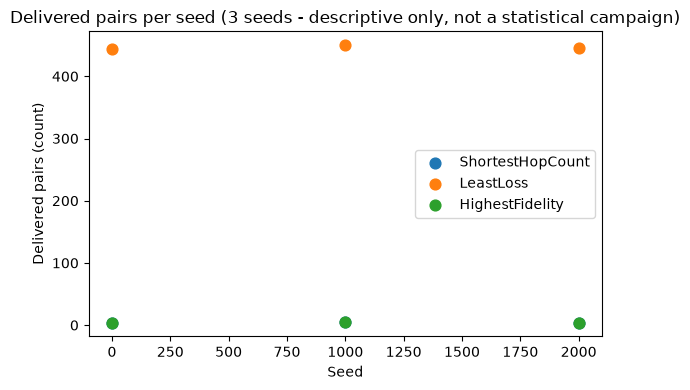

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
for strategy_name in strategies:
    subset = trials_df[trials_df["strategy"] == strategy_name]
    ax.scatter(subset["seed"], subset["observed_delivered_pairs"], label=strategy_name, s=60)
ax.set_xlabel("Seed")
ax.set_ylabel("Delivered pairs (count)")
ax.set_title(f"Delivered pairs per seed ({N_TRIALS} seeds - descriptive only, not a statistical campaign)")
ax.legend()
fig.tight_layout()
plt.show()


In [5]:
assert trials_df["observed_delivered_pairs"].notna().all()
assert (trials_df["observed_delivered_pairs"] >= 0).all()
# ShortestHopCount and HighestFidelity always pick the same route on this topology (see notebook 12);
# LeastLoss always picks the alternate one, regardless of seed (routing is seed-independent - only the
# physical outcome along the chosen route varies with the seed).
assert (trials_df[trials_df["strategy"] == "ShortestHopCount"]["route"] == "r1 -> bad -> r3").all()
assert (trials_df[trials_df["strategy"] == "LeastLoss"]["route"] == "r1 -> good1 -> good2 -> r3").all()
print("Route choice confirmed seed-independent; only the delivered pair count/timing varies across seeds.")


Route choice confirmed seed-independent; only the delivered pair count/timing varies across seeds.


## Interpretação
A rota escolhida por cada estratégia não muda entre seeds (roteamento é
uma decisão determinística sobre a topologia, independente de
aleatoriedade física) - o que varia de seed para seed é somente o
resultado observado ao longo da rota escolhida (número de pares
entregues, tempo de entrega), porque a física de geração/swap/purificação
é probabilística. `LeastLossRouting` entrega consistentemente mais pares
que `ShortestHopCount`/`HighestFidelity` neste diamante, em todas as 3
seeds testadas - mas 3 seeds só mostram uma tendência, não provam nada
estatisticamente.

## Limitações
- **3 seeds não sustentam nenhuma alegação estatística forte** (sem
  intervalo de confiança, sem teste de hipótese) - apenas mostram que o
  resultado não é uma coincidência de uma única rodada. Uma campanha
  estatística de verdade (dezenas de seeds, testes formais) é escopo da
  Fase H3.
- `planning_time_s` mede apenas a chamada a `IntentPlanner.plan` - não
  inclui a simulação em si, que domina o tempo total de execução.

## Conclusão
As três estratégias de roteamento comparadas sob as mesmas condições em
múltiplas seeds, confirmando que a escolha de rota é determinística e que
a estratégia de menor perda entrega mais pares de forma consistente nesta
topologia - sem transformar isto numa campanha estatística extensa.
